# 04 — Cross-Validation Split

**Goal:** decide how to divide the six months into training and testing folds, and
check honestly whether each fold is a fair test.

Three rules follow from what earlier notebooks found:

1. **Time order must be respected.** Training on August to predict May would be
   cheating. `TimeSeriesSplit` always trains on earlier data and tests on later.
2. **Fold boundaries land on day edges.** Splitting in the middle of a day would
   cut through rolling windows and the daily cycle.
3. **Thresholds are refitted per fold, on the training window only.** Notebook 02
   flagged that fitting them on the full series lets the definition of "Critical"
   see the future. Here we fix that, and measure how much it moves.

No model is trained here.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

PROJECT = Path.cwd().parent
PROCESSED = PROJECT / "data" / "processed"

util = pd.read_parquet(PROCESSED / "abilene_link_utilization_wide.parquet")
util.index = pd.DatetimeIndex(util.index)

CLASSES = ["Low", "Medium", "High", "Critical"]

pd.set_option("display.width", 200)
print(f"{util.shape[0]:,} timesteps x {util.shape[1]} links")

48,096 timesteps x 30 links


In [2]:
# Same styling as notebook 03.
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#c3c2b7"
INK, MUTED = "#0b0b0b", "#898781"
# Severity is an ordered scale, so the four classes get one hue getting darker,
# not four unrelated colours.
SEVERITY = {"Low": "#86b6ef", "Medium": "#3987e5",
            "High": "#1c5cab", "Critical": "#0d366b"}

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "font.size": 9, "legend.frameon": False,
})
print("style set")

style set


## Step 1 — Split on days, not on rows

`TimeSeriesSplit` divides a list into ordered chunks. If we hand it the 48,096
timesteps directly, it will cut wherever the arithmetic lands — very likely at
14:35 on some Tuesday.

Instead we hand it the **list of days**, split those, and then pull back every
timestep belonging to each day. Boundaries are on day edges by construction.

Note we split the days we *have*, not the calendar. The four gaps mean 167 days of
data across a 194-day span; a fold may therefore span a gap, which is fine — the
grid-based features from notebook 02 already return `NaN` across gaps.

In [3]:
days = pd.Index(sorted(util.index.normalize().unique()))
print(f"{len(days)} days with data, {days[0]:%Y-%m-%d} to {days[-1]:%Y-%m-%d}")
print(f"(calendar span is {(days[-1] - days[0]).days + 1} days - the difference is the gaps)")

splitter = TimeSeriesSplit(n_splits=5)

# Store each fold's day lists so the rest of the notebook can reuse them.
folds = []
for fold_number, (train_days, test_days) in enumerate(splitter.split(days), start=1):
    folds.append({"fold": fold_number,
                  "train_days": days[train_days],
                  "test_days": days[test_days]})

for f in folds:
    print(f"fold {f['fold']}: "
          f"train {f['train_days'][0]:%Y-%m-%d} to {f['train_days'][-1]:%Y-%m-%d} "
          f"({len(f['train_days'])} days)   |   "
          f"test {f['test_days'][0]:%Y-%m-%d} to {f['test_days'][-1]:%Y-%m-%d} "
          f"({len(f['test_days'])} days)")

167 days with data, 2004-03-01 to 2004-09-10
(calendar span is 194 days - the difference is the gaps)
fold 1: train 2004-03-01 to 2004-04-25 (32 days)   |   test 2004-04-26 to 2004-05-24 (27 days)
fold 2: train 2004-03-01 to 2004-05-24 (59 days)   |   test 2004-05-25 to 2004-06-20 (27 days)
fold 3: train 2004-03-01 to 2004-06-20 (86 days)   |   test 2004-06-21 to 2004-07-17 (27 days)
fold 4: train 2004-03-01 to 2004-07-17 (113 days)   |   test 2004-07-18 to 2004-08-13 (27 days)
fold 5: train 2004-03-01 to 2004-08-13 (140 days)   |   test 2004-08-14 to 2004-09-10 (27 days)


The training window grows each fold while the test window stays at 27 days — the
standard expanding-window arrangement. Every test period sits strictly after its
training period.

## Step 2 — Refit the thresholds on each fold's training window

This is the correction promised in notebook 02. For each fold we recompute the
per-link p50/p80/p95 **using only that fold's training rows**, then use those cut
points to label both the training and the test rows.

Labelling the test set with *training* thresholds is the point: at prediction time
you would not know the test period's own distribution.

In [4]:
def fit_thresholds(block):
    """Per-link p50/p80/p95 for one block of rows."""
    thresholds = block.quantile([0.50, 0.80, 0.95]).T
    thresholds.columns = ["p50", "p80", "p95"]
    thresholds.index.name = "link"
    return thresholds


def apply_labels(block, thresholds):
    """Same rule as notebook 02: count how many cut points each value exceeds."""
    codes = ((block > thresholds["p50"]).astype(int)
             + (block > thresholds["p80"]).astype(int)
             + (block > thresholds["p95"]).astype(int))
    return pd.DataFrame(np.array(CLASSES)[codes.to_numpy()],
                        index=block.index, columns=block.columns)


for f in folds:
    f["train"] = util[util.index.normalize().isin(f["train_days"])]
    f["test"] = util[util.index.normalize().isin(f["test_days"])]
    f["thresholds"] = fit_thresholds(f["train"])       # TRAIN ONLY

print("thresholds refitted for each fold, using training rows only")
print("\nfold 1, first 3 links:")
print(folds[0]["thresholds"].head(3).round(3).to_string())

thresholds refitted for each fold, using training rows only

fold 1, first 3 links:
                  p50    p80    p95
link                               
ATLA-M5,ATLAng  0.071  0.102  0.140
ATLAng,ATLA-M5  0.000  0.101  0.205
ATLAng,HSTNng   3.171  4.774  5.816


### Does refitting actually change anything?

If the thresholds barely moved, this would be a technicality. Compare the p95 (the
"Critical" line) across the five folds.

In [5]:
p95_by_fold = pd.DataFrame({f"fold {f['fold']}": f["thresholds"]["p95"] for f in folds})
p95_by_fold["full series"] = fit_thresholds(util)["p95"]

# How much does each link's Critical line move between its highest and lowest fold?
fold_columns = [c for c in p95_by_fold.columns if c != "full series"]
movement = (p95_by_fold[fold_columns].max(axis=1)
            / p95_by_fold[fold_columns].min(axis=1)).sort_values(ascending=False)

print("links whose Critical threshold moves most across folds:\n")
print(pd.concat([p95_by_fold.loc[movement.head(6).index].round(2),
                 movement.head(6).rename("max/min").round(2)], axis=1).to_string())

print(f"\nlinks moving more than 2x across folds: {(movement > 2).sum()} of {len(movement)}")
print(f"median movement across all links       : {movement.median():.2f}x")

links whose Critical threshold moves most across folds:

               fold 1  fold 2  fold 3  fold 4  fold 5  full series  max/min
link                                                                       
DNVRng,SNVAng    3.58   21.30    6.46    3.66    3.51         3.45     6.07
SNVAng,LOSAng    3.72   21.98    7.98    5.43    4.62         4.78     5.91
IPLSng,KSCYng   37.64   29.57   22.72    8.17    7.55         7.46     4.99
CHINng,IPLSng   38.44   30.35   23.59    9.48    8.75         8.76     4.39
KSCYng,DNVRng    6.62   23.03    8.51    6.40    6.21         6.22     3.71
CHINng,NYCMng    6.66    5.82    5.45    5.24    5.09         5.06     1.31

links moving more than 2x across folds: 5 of 30
median movement across all links       : 1.16x


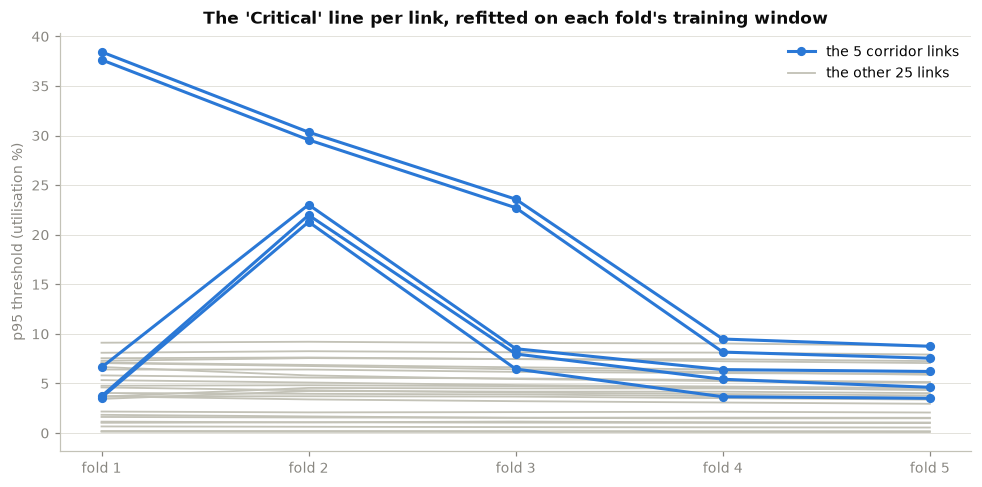

In [6]:
CORRIDOR = ["CHINng,IPLSng", "IPLSng,KSCYng", "KSCYng,DNVRng",
            "DNVRng,SNVAng", "SNVAng,LOSAng"]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(fold_columns))

for link in p95_by_fold.index:
    if link not in CORRIDOR:
        ax.plot(x, p95_by_fold.loc[link, fold_columns], color=GREY,
                linewidth=1.2, zorder=1)
for link in CORRIDOR:
    ax.plot(x, p95_by_fold.loc[link, fold_columns], color=BLUE,
            linewidth=2, marker="o", markersize=5, zorder=3)

# The two groups overlap in value range, so an arrow pointing at "the grey ones"
# would be ambiguous - a legend with proxy lines is unambiguous.
ax.plot([], [], color=BLUE, linewidth=2, marker="o", markersize=5,
        label="the 5 corridor links")
ax.plot([], [], color=GREY, linewidth=1.2, label="the other 25 links")
ax.legend(loc="upper right")

ax.set_xticks(list(x))
ax.set_xticklabels(fold_columns)
ax.set_ylabel("p95 threshold (utilisation %)")
ax.set_title("The 'Critical' line per link, refitted on each fold's training window")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

**Refitting matters, and it matters a lot — but only on five links.**

`CHINng,IPLSng` has a Critical line of **38.4%** in fold 1 and **8.8%** by fold 5.
The reason is straightforward: fold 1's training window is only 32 days, and eight
of those days are the April bursts, so the extreme traffic is a large share of
what the model considers normal. As the window grows, the bursts get diluted.

Two of the corridor links move **non-monotonically** — `DNVRng,SNVAng` goes 3.6 →
21.3 → 6.5 → 3.7 → 3.5. Fold 2's window is the one that happens to contain the
whole of the April/May episode as a big fraction of its length.

The other 25 links move by less than 1.3×. So this is entirely an artefact of the
two large transfers identified in notebook 03, not a general instability.

## Step 3 — Class distribution per fold

Now the question that matters: with thresholds fitted on training data, what does
each fold's test set actually look like?

In [7]:
records = []
for f in folds:
    for part in ["train", "test"]:
        block = f[part]
        labels = apply_labels(block, f["thresholds"])
        share = pd.Series(labels.to_numpy().ravel()).value_counts(normalize=True) * 100
        records.append({
            "fold": f["fold"], "part": part,
            "from": block.index.min().date(), "to": block.index.max().date(),
            "days": block.index.normalize().nunique(),
            "rows": block.size,
            **{c: round(share.get(c, 0.0), 2) for c in CLASSES},
        })

summary = pd.DataFrame(records)
print(summary.to_string(index=False))

 fold  part       from         to  days    rows   Low  Medium  High  Critical
    1 train 2004-03-01 2004-04-25    32  276480 50.31   29.69 15.00      5.00
    1  test 2004-04-26 2004-05-24    27  233280 45.98   29.92 17.17      6.93
    2 train 2004-03-01 2004-05-24    59  509760 50.00   30.00 15.00      5.00
    2  test 2004-05-25 2004-06-20    27  233280 68.25   24.91  4.79      2.05
    3 train 2004-03-01 2004-06-20    86  743040 50.00   30.00 15.00      5.00
    3  test 2004-06-21 2004-07-17    27  233280 74.95   20.27  3.08      1.70
    4 train 2004-03-01 2004-07-17   113  976320 50.00   30.00 15.00      5.00
    4  test 2004-07-18 2004-08-13    27  233280 69.59   25.71  3.77      0.92
    5 train 2004-03-01 2004-08-13   140 1209600 50.00   30.00 15.00      5.00
    5  test 2004-08-14 2004-09-10    27  233280 47.67   29.37 12.82     10.14


The **training** rows come out at 50 / 30 / 15 / 5 — as they must, since the
thresholds are that window's own percentiles.

**Except fold 1**, which lands at 50.31 / 29.69 / 15.00 / 5.00. That is not a bug,
and it is worth understanding because it is a real property of the data. Look at
fold 1's thresholds printed above: `ATLAng,ATLA-M5` has **p50 = 0.000**. Notebook
03 found that link reads exactly zero for the whole of April — and April is a large
share of fold 1's short 32-day window. With that many tied zeros, the "≤ p50" rule
sweeps all of them into Low, so Low overshoots 50%.

Percentiles only split cleanly when values are distinct. On the full series the
ties were too few to matter; on a short window containing a month of zeros, they
show up. Only fold 1 is affected.

The **test** rows are the interesting column, and they are all over the place.

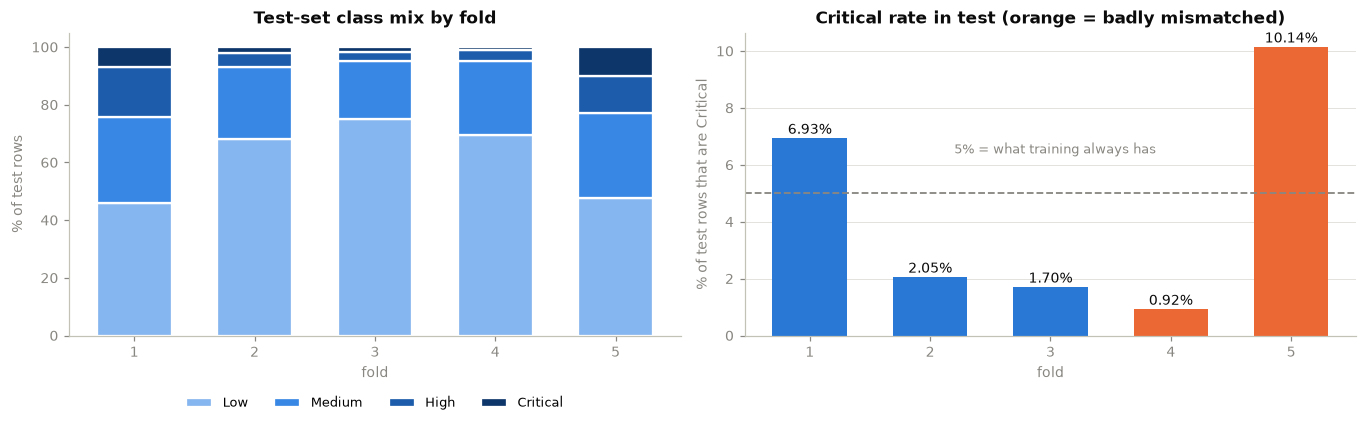

            from          to    rows    Low  Medium   High  Critical
fold                                                                
1     2004-04-26  2004-05-24  233280  45.98   29.92  17.17      6.93
2     2004-05-25  2004-06-20  233280  68.25   24.91   4.79      2.05
3     2004-06-21  2004-07-17  233280  74.95   20.27   3.08      1.70
4     2004-07-18  2004-08-13  233280  69.59   25.71   3.77      0.92
5     2004-08-14  2004-09-10  233280  47.67   29.37  12.82     10.14


In [8]:
test_rows = summary[summary.part == "test"].set_index("fold")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))

# Left: full class mix per fold, stacked. White edges give the 2px separation
# the segments need to read as distinct.
bottom = np.zeros(len(test_rows))
for cls in CLASSES:
    axes[0].bar(test_rows.index, test_rows[cls], bottom=bottom, label=cls,
                color=SEVERITY[cls], width=0.62,
                edgecolor="white", linewidth=1.5)
    bottom += test_rows[cls].to_numpy()
axes[0].set_xlabel("fold")
axes[0].set_ylabel("% of test rows")
axes[0].set_title("Test-set class mix by fold")
axes[0].set_xticks(test_rows.index)
# Legend below the axes - inside the plot it sits on top of the bars.
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.16),
               ncol=4, fontsize=8.5)

# Right: just Critical, because that is where the folds diverge most.
colours = [ORANGE if v < 1.5 or v > 9 else BLUE for v in test_rows["Critical"]]
bars = axes[1].bar(test_rows.index, test_rows["Critical"], color=colours, width=0.62)
axes[1].axhline(5.0, color=MUTED, linestyle="--", linewidth=1.2)
axes[1].annotate("5% = what training always has", xy=(3.4, 5.0), xytext=(2.2, 6.4),
                 color=MUTED, fontsize=8.5)
for bar, value in zip(bars, test_rows["Critical"]):
    axes[1].annotate(f"{value:.2f}%", xy=(bar.get_x() + bar.get_width() / 2, value),
                     xytext=(0, 3), textcoords="offset points",
                     ha="center", fontsize=9, color=INK)
axes[1].set_xlabel("fold")
axes[1].set_ylabel("% of test rows that are Critical")
axes[1].set_title("Critical rate in test (orange = badly mismatched)")
axes[1].set_xticks(test_rows.index)
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

print(test_rows[["from", "to", "rows"] + CLASSES].to_string())

### The folds are not testing the same thing

| Fold | Test period | Critical % | What it contains |
|---|---|---|---|
| 1 | 26 Apr – 24 May | **6.93%** | the tail of the April/May transfers |
| 2 | 25 May – 20 Jun | 2.05% | quiet |
| 3 | 21 Jun – 17 Jul | 1.70% | quiet |
| 4 | 18 Jul – 13 Aug | **0.92%** | the calmest stretch in the data |
| 5 | 14 Aug – 10 Sep | **10.14%** | the September east-bound episode |

Training is always 5% Critical. Test ranges from **0.92% to 10.14% — an 11×
spread**, and only fold 1 is anywhere near its training balance.

Folds 3 and 4 are also heavily skewed toward Low (75.0% and 69.6%), while fold 5
sits at 47.7% Low with 12.8% High.

## Step 4 — A detail day-edge snapping does *not* fix

Snapping to day edges keeps rolling windows from being cut mid-day. But one
feature has a window exactly one day long: **`lag_288`**, and `roll_*_288` with it.

For the rows on the **first test day**, that feature reaches back 288 steps —
straight into the training window.

In [9]:
for f in folds:
    first_test_day = f["test_days"][0]
    rows_on_first_day = (f["test"].index.normalize() == first_test_day).sum()
    print(f"fold {f['fold']}: test begins {first_test_day:%Y-%m-%d}, "
          f"{rows_on_first_day} timesteps whose lag_288 points into the training window")

per_fold = 288 * util.shape[1]
print(f"\nthat is {per_fold:,} (timestep, link) rows per fold, "
      f"{per_fold / (288 * 27 * util.shape[1]) * 100:.1f}% of each test set")

fold 1: test begins 2004-04-26, 288 timesteps whose lag_288 points into the training window
fold 2: test begins 2004-05-25, 288 timesteps whose lag_288 points into the training window
fold 3: test begins 2004-06-21, 288 timesteps whose lag_288 points into the training window
fold 4: test begins 2004-07-18, 288 timesteps whose lag_288 points into the training window
fold 5: test begins 2004-08-14, 288 timesteps whose lag_288 points into the training window

that is 8,640 (timestep, link) rows per fold, 3.7% of each test set


**Is this a problem?** Mostly no, and it is worth being precise about why.

Reaching backwards in time is what a deployed model does — at 00:05 on the first
test day, yesterday's traffic genuinely *is* available. Information only flows from
past to future, so this is not leakage in the sense that inflates scores.

What it does mean is that the first test day is slightly easier than the rest, and
that the strict reading of "features never cross a fold boundary" is not satisfied
by day-edge snapping alone. If you want that guarantee, drop the first day of each
test fold — an **embargo**:

In [10]:
# Optional: an embargo removing the first day of each test fold, so no test row's
# features reach into training. NOT applied below - shown so the cost is visible.
embargo_cost = []
for f in folds:
    kept = f["test_days"][1:]
    embargo_cost.append({
        "fold": f["fold"],
        "test days now": len(kept),
        "rows dropped": 288 * util.shape[1],
        "% of test lost": round(288 / (288 * len(f["test_days"])) * 100, 1),
    })
print(pd.DataFrame(embargo_cost).to_string(index=False))
print("\nCheap - about 3.7% of each test set. Left as a decision for the "
      "modelling step\nrather than applied here.")

 fold  test days now  rows dropped  % of test lost
    1             26          8640             3.7
    2             26          8640             3.7
    3             26          8640             3.7
    4             26          8640             3.7
    5             26          8640             3.7

Cheap - about 3.7% of each test set. Left as a decision for the modelling step
rather than applied here.


## Step 5 — Save the fold definitions

So the modelling notebook uses exactly these splits rather than recomputing them.

In [11]:
fold_table = pd.DataFrame([
    {"fold": f["fold"], "part": part, "day": day.date()}
    for f in folds for part in ["train", "test"] for day in f[f"{part}_days"]
])
fold_table.to_csv(PROCESSED / "cv_folds.csv", index=False)

thresholds_table = pd.concat(
    {f["fold"]: f["thresholds"] for f in folds}, names=["fold", "link"])
thresholds_table.to_csv(PROCESSED / "cv_fold_thresholds.csv")

print(f"saved cv_folds.csv ({len(fold_table):,} fold-day rows)")
print(f"saved cv_fold_thresholds.csv ({len(thresholds_table)} fold-link thresholds)")

saved cv_folds.csv (565 fold-day rows)
saved cv_fold_thresholds.csv (150 fold-link thresholds)


In [12]:
# Sanity checks.
checks = {
    "5 folds": len(folds) == 5,
    "every test period starts after its training period ends":
        all(f["test_days"][0] > f["train_days"][-1] for f in folds),
    "no day appears in both train and test of the same fold":
        all(len(set(f["train_days"]) & set(f["test_days"])) == 0 for f in folds),
    "training windows grow":
        all(len(folds[i]["train_days"]) < len(folds[i + 1]["train_days"])
            for i in range(len(folds) - 1)),
    "every fold boundary is a day edge":
        all(f["test"].index.normalize().isin(f["test_days"]).all() for f in folds),
    "thresholds fitted on training rows only":
        all(f["thresholds"].equals(fit_thresholds(f["train"])) for f in folds),
    "all 30 links have thresholds in every fold":
        all(len(f["thresholds"]) == 30 for f in folds),
}
for name, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
print(f"\n{sum(checks.values())}/{len(checks)} checks passed")

[PASS] 5 folds
[PASS] every test period starts after its training period ends
[PASS] no day appears in both train and test of the same fold
[PASS] training windows grow
[PASS] every fold boundary is a day edge
[PASS] thresholds fitted on training rows only
[PASS] all 30 links have thresholds in every fold

7/7 checks passed


## Summary — which folds are weak tests, and why

**Fold 4 is the weakest test of general quality.** Its test window (18 Jul –
13 Aug) is the calmest stretch in the whole dataset: **0.92% Critical**, against
5% in training. A model tuned on a 5% base rate will over-predict Critical here,
and precision will look bad for a reason that has nothing to do with the model.
With so few positives, the Critical score will also be noisy.

**Fold 5 is the mirror image.** Its test window catches the September east-bound
episode — **10.14% Critical**, double the training rate. A model will
under-predict, and recall will suffer. It is not a bad fold; it is the *hardest*
one, and arguably the most informative, because it is the only fold that tests
whether the model handles an episode it was not trained on.

**Fold 1 is the best-matched** (6.93% vs 5%) but has the shortest training window
(32 days) and the most distorted thresholds — its Critical line for the corridor
links sits at ~38% versus ~9% by fold 5. It is well balanced for the wrong reason:
its training data contains the April bursts, so its idea of "normal" is inflated.
It is also the only fold whose training labels are not an exact 50/30/15/5 split,
because a month of tied zero readings on `ATLAng,ATLA-M5` falls inside its window.

**Folds 2 and 3 are the closest to routine conditions** and are probably the
cleanest read on ordinary-traffic performance.

### What to do about it (for the modelling step, not decided here)

- **Report per-fold scores, never just the mean.** Averaging 0.92% and 10.14%
  Critical produces a number that describes no real situation.
- **Use metrics that survive class imbalance** — per-class precision/recall or
  balanced accuracy rather than plain accuracy. On fold 4, always predicting "Low"
  scores 69.6%.
- **Expect fold 5 to look worst,** and treat that as the honest headline rather
  than an outlier to drop. Predicting an unfamiliar traffic episode is exactly the
  capability the adaptive-routing half of this project needs.
- The alternative — dropping the April/May and September episodes to get uniform
  folds — would make the numbers look better and the project worth less. Notebook
  03 showed these episodes are a recurring feature of this network, not
  contamination.